In [207]:
# Import necessary packages

import os
import glob
import sys
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor
import logging

import tifffile as tiff
import numpy as np
import matplotlib.pyplot as plt
import plotnine as p9
import pandas as pd
from skimage import feature, io
from scipy.stats import norm
from scipy.ndimage import label, find_objects

# Make path for scripts relative to the working directory
sys.path.insert(0, '../src')  # Adjust the path as needed

# Setup basic logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

In [209]:
# Define path names and load some basic functions for reading in files

# Define the location of the files to read
parent_directory = "/Users/nestor/Dropbox/Work/DIMMERs/microscope-data" # data directory
repo_directory = "/Users/nestor/Documents/NYU-ISG/python_image-analysis" # analysis code directory
experiment_list = ["08052024_pDIMMERs", "08122024_pDIMMERs",
                  "10032024_pDIMMERs", "10072024_pDIMMERs"] # this will be changed for each experiment

# Define the folder structure within each experiment
file_folders = {
    "image": "MIPs/MIPs_multichannel/", 
    "mask_n": "segmentation-masks/nuclei_masks/"
}

# Load the function img_loadr() 
from load_files import img_loadr

def extract_base_name(filename):
    """
    Extract the base name from the file name without removing important parts of the name,
    such as the date and experiment information, while stripping the channel prefixes from masks.
    """
    name = os.path.basename(filename)

    # Only remove 'C1-', 'C2-', etc., from mask files
    if name.startswith(("C1-", "C2-", "C3-", "C4-", "C5-")):
        name = name[3:]  # Remove the first 3 characters (e.g., 'C1-', 'C2-', etc)
    
    # Remove the "_cp_masks" suffix for masks or ".ome" from image files if present
    name = name.replace("_cp_masks", "").replace(".ome", "")
    
    # Remove the file extension
    base_name = os.path.splitext(name)[0]
    
    return base_name

In [211]:
# CHUNK 1 # 
# Load maximum intensity projection (MIP) files
# and segmentation masks for images in all experiments listed

# Create a dictionary to store data across multiple experiments
all_experiments_data = {}

# Iterate through each experiment in experiment_list
for experiment in experiment_list:
    # Initialize data structures for the current experiment
    exp_data = {
        "all_images": {"image": [], "mask_n": []},
        "file_names": {"image": [], "mask_n": []},
        "base_names": {"image": [], "mask_n": []},
        "errors": []
    }

    # Read in the experimental groups reference file for each experiment
    exp_groups = pd.read_csv(os.path.join(parent_directory, experiment, "experimental-groups.csv"))

    # Process each file type using img_loadr
    with ThreadPoolExecutor(max_workers=4) as executor:
        for f in file_folders:
            file_path = os.path.join(parent_directory, experiment, file_folders[f])
            files = glob.glob(os.path.join(file_path, "*.tif"))
            results = executor.map(img_loadr, files)

            for result in results:
                image, filename = result
                if image is not None:
                    exp_data["all_images"][f].append(image)
                    exp_data["file_names"][f].append(filename)
                    exp_data["base_names"][f].append(extract_base_name(filename))
                else:
                    exp_data["errors"].append(f"Error loading {filename}")

    # Log the completion of processing for this experiment
    if exp_data["errors"]:
        logging.error(f"{experiment}: Completed with errors in {len(exp_data['errors'])} files.")
    else:
        logging.info(f"{experiment}: All images and masks processed successfully without errors.")
    
    # Store the experiment's data under its name
    all_experiments_data[experiment] = exp_data

# Optional: Summary of processed files for all experiments
for experiment, data in all_experiments_data.items():
    logging.info(f"{experiment}: Processed {len(data['file_names']['image'])} images and {len(data['file_names']['mask_n'])} nuclei masks.")
    
# Now for each experiment, all_images["image"] contains all the images (MIPs), 
# all_images["mask_n"] contains all the nuclei masks and 

2024-11-06 11:31:07,769 - INFO - 08052024_pDIMMERs: All images and masks processed successfully without errors.
2024-11-06 11:31:09,624 - INFO - 08122024_pDIMMERs: All images and masks processed successfully without errors.
2024-11-06 11:31:11,576 - INFO - 10032024_pDIMMERs: All images and masks processed successfully without errors.
2024-11-06 11:31:13,035 - INFO - 10072024_pDIMMERs: All images and masks processed successfully without errors.
2024-11-06 11:31:13,042 - INFO - 08052024_pDIMMERs: Processed 67 images and 67 nuclei masks.
2024-11-06 11:31:13,043 - INFO - 08122024_pDIMMERs: Processed 113 images and 113 nuclei masks.
2024-11-06 11:31:13,043 - INFO - 10032024_pDIMMERs: Processed 138 images and 138 nuclei masks.
2024-11-06 11:31:13,043 - INFO - 10072024_pDIMMERs: Processed 84 images and 84 nuclei masks.


In [7]:
# Check dimensions of a given set of images, to verify they're correct (optional)

# Define function to check dimensions of images and masks
def img_sizr(image_types, file_indices, all_images):
    for f in file_indices:
        for image_type in image_types:
            try:
                image_shape = all_images[image_type][f].shape
                logging.info(f"File {f} ({image_type}): {image_shape}")
            except IndexError:
                logging.warning(f"File index {f} for {image_type} is out of range.")
            except KeyError:
                logging.error(f"Image type {image_type} does not exist.")

# Define the list of image types to check
image_types_to_check = ['image', 'mask_n']  # Add 'mask_b' if you want to check background masks too

# And the list of file indices to check
test_files = [3, 4]

# Loop over each experiment in all_experiments_data
for experiment, data in all_experiments_data.items():
    logging.info(f"Running dimension check for experiment: {experiment}")
    img_sizr(image_types_to_check, test_files, data["all_images"])

2024-11-04 15:59:02,779 - INFO - Running dimension check for experiment: 08052024_pDIMMERs
2024-11-04 15:59:02,784 - INFO - File 3 (image): (3, 2048, 2048)
2024-11-04 15:59:02,785 - INFO - File 3 (mask_n): (2048, 2048)
2024-11-04 15:59:02,787 - INFO - File 4 (image): (3, 2048, 2048)
2024-11-04 15:59:02,788 - INFO - File 4 (mask_n): (2048, 2048)
2024-11-04 15:59:02,790 - INFO - Running dimension check for experiment: 08122024_pDIMMERs
2024-11-04 15:59:02,790 - INFO - File 3 (image): (3, 2048, 2048)
2024-11-04 15:59:02,790 - INFO - File 3 (mask_n): (2048, 2048)
2024-11-04 15:59:02,791 - INFO - File 4 (image): (3, 2048, 2048)
2024-11-04 15:59:02,791 - INFO - File 4 (mask_n): (2048, 2048)
2024-11-04 15:59:02,792 - INFO - Running dimension check for experiment: 10032024_pDIMMERs
2024-11-04 15:59:02,792 - INFO - File 3 (image): (3, 2048, 2048)
2024-11-04 15:59:02,792 - INFO - File 3 (mask_n): (2048, 2048)
2024-11-04 15:59:02,792 - INFO - File 4 (image): (3, 2048, 2048)
2024-11-04 15:59:02,79

In [213]:
# CHUNK 2 #
# Match image indices to mask indices, to make sure they're paired correctly
# as they may not have been read in the same order

# Loop over each experiment in all_experiments_data to match image and mask indices
for experiment, data in all_experiments_data.items():
    logging.info(f"Matching image indices to mask indices for experiment: {experiment}")

    # Access the base names for images and masks in this experiment
    image_base_names = data['base_names']['image']
    mask_base_names = data['base_names']['mask_n']

    # Convert list of mask base names to a dictionary for faster lookup
    mask_name_to_index = {base_name: idx for idx, base_name in enumerate(mask_base_names)}

    # Match each image with its corresponding mask using base names
    matched_indices = []
    missing_masks = 0
    for img_index, img_base_name in enumerate(image_base_names):
        mask_index = mask_name_to_index.get(img_base_name)

        if mask_index is not None:
            matched_indices.append((img_index, mask_index))
        else:
            missing_masks += 1
            logging.warning(f"No matching mask found for image base name: {img_base_name} in experiment {experiment}")

    # Log the results of the matching for this experiment
    logging.info(f"{experiment}: Matched {len(matched_indices)} images with masks. Missing masks for {missing_masks} images.")

    # Optionally, store matched_indices in the experiment's data if needed for downstream analysis
    data["matched_indices"] = matched_indices
    
# Now, matched_indices contains pairs of indices for matched image and mask

2024-11-06 11:31:22,308 - INFO - Matching image indices to mask indices for experiment: 08052024_pDIMMERs
2024-11-06 11:31:22,311 - INFO - 08052024_pDIMMERs: Matched 67 images with masks. Missing masks for 0 images.
2024-11-06 11:31:22,313 - INFO - Matching image indices to mask indices for experiment: 08122024_pDIMMERs
2024-11-06 11:31:22,315 - INFO - 08122024_pDIMMERs: Matched 113 images with masks. Missing masks for 0 images.
2024-11-06 11:31:22,316 - INFO - Matching image indices to mask indices for experiment: 10032024_pDIMMERs
2024-11-06 11:31:22,317 - INFO - 10032024_pDIMMERs: Matched 138 images with masks. Missing masks for 0 images.
2024-11-06 11:31:22,318 - INFO - Matching image indices to mask indices for experiment: 10072024_pDIMMERs
2024-11-06 11:31:22,320 - INFO - 10072024_pDIMMERs: Matched 84 images with masks. Missing masks for 0 images.


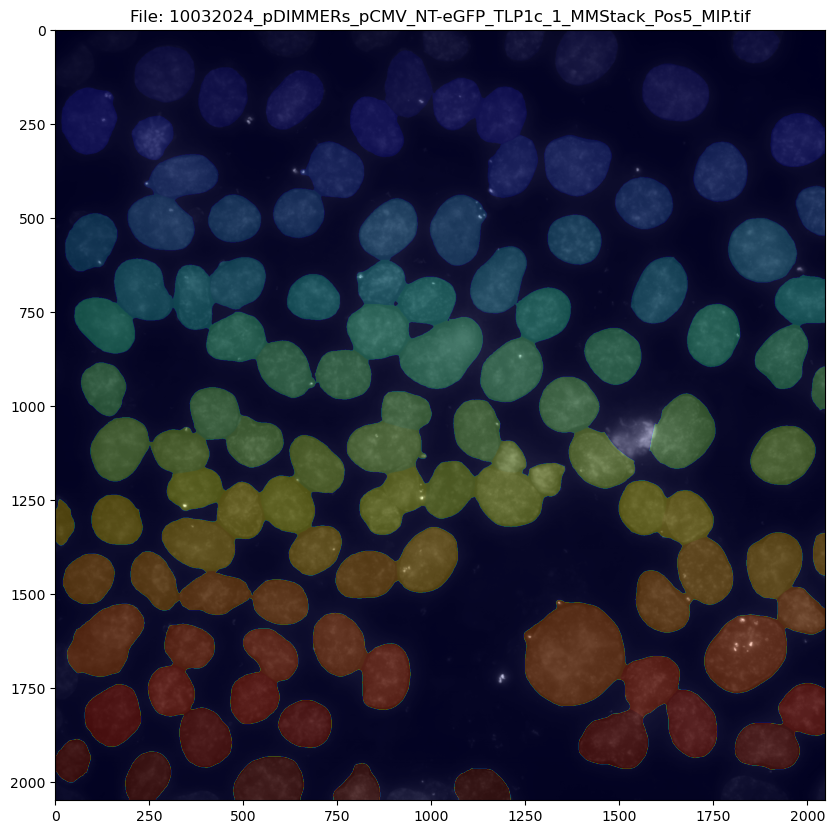

In [215]:
# Overlay the corresponding mask on a channel (given as c) of a given image
# to visually inspect

# Specify the index of the image to check
# and the channel to plot — remember CH1 for ImageJ but channel 0 for Python!
e_index = 2
image_index = 4 # Replace with the desired index
c = 0 # remember the channel order in these images

# Access the specific experiment's data
experiment_data = all_experiments_data[experiment_list[e_index]]

# Find the corresponding mask index for the specified image
# and define the image and mask pair
matched_indices = experiment_data["matched_indices"]
mask_index = [pair[1] for pair in matched_indices if pair[0] == image_index][0]

# Define the image and mask pair
my_image = experiment_data['all_images']['image'][image_index]
image_file = experiment_data['file_names']['image'][image_index]
my_mask_n = experiment_data['all_images']['mask_n'][mask_index]

# Select the c channel
channel_image = my_image[c, ...]

# Overlay the mask on the rest of the image if they have the same dimensions
if channel_image.shape != my_mask_n.shape:
    print("Warning: The image and mask sizes do not match. Please check your data.")
else:
    overlay = np.ma.masked_where(my_mask_n == 0, my_mask_n)
    plt.figure(figsize=(10, 10))
    plt.imshow(channel_image, cmap='gray')  # Display the selected channel in grayscale
    plt.imshow(my_mask_n, cmap='jet', alpha=0.25)  # Overlay the mask with transparency
    plt.title(f'File: {image_file}')
    #plt.axis('off')  # Turn off axis labels
    plt.show()

In [13]:
# CHUNK 3 (optional) # 
# Background analysis

# Define a function that identifies all potential background regions (ROI = 0)
def find_background_regions(nuclear_mask):
    """
    Identifies and labels distinct background regions (where ROI == 0) in a nuclear mask.

    Parameters:
    - nuclear_mask: numpy array representing the nuclear mask, where 0 denotes background.

    Returns:
    - labeled_background: numpy array with the same shape as nuclear_mask, where each
                          distinct background region is labeled with a unique integer,
                          and non-background areas are labeled as 0.
    """
    # Create a binary array where True denotes background
    background = (nuclear_mask == 0)

    # Use scipy.ndimage.label to label connected components in the background
    labeled_background, num_features = label(background)

    # The function labels all connected components. We will zero out non-background regions
    # which have been inadvertently labeled by reversing the initial condition.
    labeled_background[nuclear_mask != 0] = 0

    return labeled_background, num_features

In [17]:
# Initialize storage dictionaries for each experiment's labeled backgrounds, region counts, and metrics
labeled_bks = {}
bk_region_deets = {}

# Process each experiment in all_experiments_data
for experiment, data in all_experiments_data.items():
    logging.info(f"Processing background regions for experiment: {experiment}")

    # Initialize lists to store labeled backgrounds and region details for the current experiment
    ex_labeled_bks = []
    ex_bk_region_deets = []

    # For each nuclear mask in the current experiment, find background regions
    for mask_index, nuclear_mask in enumerate(data['all_images']['mask_n']):
        labeled_bg, num_features = find_background_regions(nuclear_mask)
        ex_labeled_bks.append(labeled_bg)
        region_details = []

        # Fetch the corresponding image for intensity calculations
        corresponding_image = data['all_images']['image'][mask_index]

        # Process each background region
        for region_label in range(1, num_features + 1):
            region_mask = (labeled_bg == region_label)
            region_area = np.sum(region_mask)
            region_avg_intensities = []
            region_median_intensities = []

            # Calculate average and median intensity per channel within the region
            for channel_index in range(corresponding_image.shape[0]):
                channel_data = corresponding_image[channel_index]
                avg_intensity = np.mean(channel_data[region_mask])
                median_intensity = np.median(channel_data[region_mask])
                region_avg_intensities.append(avg_intensity)
                region_median_intensities.append(median_intensity)

            # Store details for the current region
            region_details.append({
                'area': region_area,
                'avg_intensities': region_avg_intensities,
                'median_intensities': region_median_intensities
            })

        # Store details for all regions in the current mask
        ex_bk_region_deets.append(region_details)

    # Store results for the current experiment
    labeled_bks[experiment] = ex_labeled_bks
    bk_region_deets[experiment] = ex_bk_region_deets

# Now, labeled_bks and bk_region_deets store results for each experiment

2024-11-01 12:57:11,745 - INFO - Processing background regions for experiment: 08052024_pDIMMERs
2024-11-01 12:57:26,559 - INFO - Processing background regions for experiment: 08122024_pDIMMERs
2024-11-01 12:58:01,151 - INFO - Processing background regions for experiment: 10032024_pDIMMERs
2024-11-01 12:58:13,208 - INFO - Processing background regions for experiment: 10072024_pDIMMERs


In [ ]:
# Flatten the data structure into a list of dictionaries
data_for_df = []
for experiment, regions_list in bk_region_deets.items():
    for mask_index, regions in enumerate(regions_list):
        # Get the mask filename for the current experiment and mask index
        mask_filename = all_experiments_data[experiment]['file_names']['mask_n'][mask_index]
        
        for region_index, details in enumerate(regions):
            # Create a dictionary for each region that includes experiment, mask index, region index, and mask filename
            region_dict = {
                'experiment': experiment,  # Add experiment as a column
                'mask_index': mask_index,
                'region_index': region_index + 1,  # 1-based index for region
                'mask_filename': mask_filename,  # Include the filename of the mask
                'area': details['area']
            }

            # Add average intensities for each channel
            for channel_index, avg_intensity in enumerate(details['avg_intensities']):
                region_dict[f'avg_intensity_channel_{channel_index}'] = avg_intensity

            # Add median intensities for each channel
            for channel_index, median_intensity in enumerate(details['median_intensities']):
                region_dict[f'median_intensity_channel_{channel_index}'] = median_intensity

            # Append the dictionary to the list
            data_for_df.append(region_dict)

# Create a DataFrame from the list of dictionaries
bk_df = pd.DataFrame(data_for_df)
print(bk_df.head())

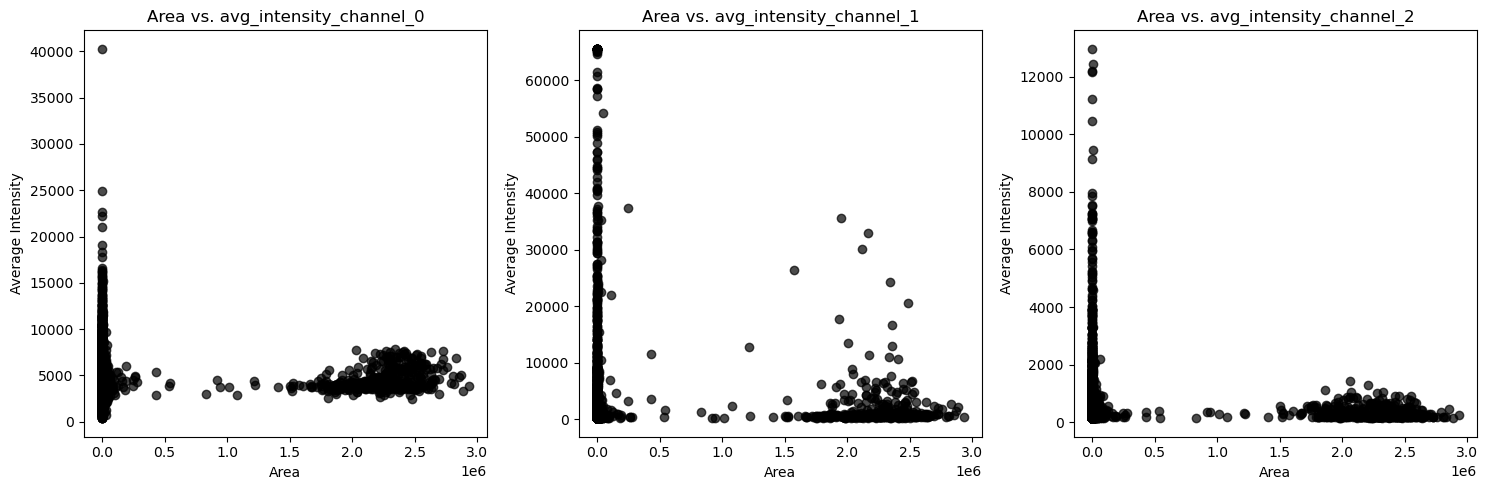

In [23]:
# Determine the number of channels from the DataFrame column names
channel_columns = [col for col in bk_df.columns if 'avg_intensity_channel_' in col]
num_channels = len(channel_columns)

# Set up the figure with subplots arranged side by side
fig, axes = plt.subplots(1, num_channels, figsize=(15, 5))  # Adjust total width and height as needed

if num_channels == 1:  # If there's only one channel, make sure 'axes' is iterable
    axes = [axes]

# Plot each channel's intensity against the area
for idx, channel in enumerate(channel_columns):
    ax = axes[idx]
    ax.scatter(bk_df['area'], bk_df[channel], color='black', alpha=0.7)
    ax.set_title(f'Area vs. {channel}')
    ax.set_xlabel('Area')
    ax.set_ylabel('Average Intensity')

# Ensure the layout is organized to prevent overlap of plot elements
plt.tight_layout()
plt.show()

The background objects fall clearly into two categories, one with large objects that have low intensity values (the true background) and one with small objects of varying intensity levels (some as high as the nuclei, the true signal). If we do background subtraction, we should only use the large objects, with low intensity values

In [217]:
# CHUNK 3 (cont) #
# Incorporate the same operations ran above into a single step that extracts the largest background ROI
# and calculates the corresponding intensities

from background_subtraction import get_largest_background

# Initialize a list to store background values
bk_values = []

# Loop over each experiment in the data
for experiment, data in all_experiments_data.items():
    # Use matched indices to correctly process each image and its corresponding mask within the experiment
    for img_index, mask_index in data["matched_indices"]:
        image = data['all_images']['image'][img_index]  # Get the correct image by image index
        mask = data['all_images']['mask_n'][mask_index]  # Get the corresponding mask by mask index

        # Get background data for the current image-mask pair
        result = get_largest_background(mask, image, img_index)
        area = result['area']
        
        # Collect data for each channel from the background analysis
        for channel, (avg_intensity, median_intensity) in enumerate(zip(result['average_intensities'], result['median_intensities'])):
            bk_values.append({
                'experiment': experiment,  # Add experiment name
                'image_index': img_index,  # Store image index to track which image this data belongs to
                'mask_index': mask_index,  # Also store mask index for completeness
                'channel': channel,
                'avg_intensity': avg_intensity,
                'median_intensity': median_intensity,
                'area': area
            })

# Convert the list of formatted dictionaries to a DataFrame
bk_df = pd.DataFrame(bk_values)
print(bk_df.head())

          experiment  image_index  mask_index  channel  avg_intensity  \
0  08052024_pDIMMERs            0          31        0    2435.204452   
1  08052024_pDIMMERs            0          31        1     370.483366   
2  08052024_pDIMMERs            0          31        2     354.618821   
3  08052024_pDIMMERs            1           5        0    2359.435582   
4  08052024_pDIMMERs            1           5        1    3632.672533   

   median_intensity     area  
0            2273.0  2238193  
1             349.0  2238193  
2             212.0  2238193  
3            1990.0  2661623  
4            1687.0  2661623  


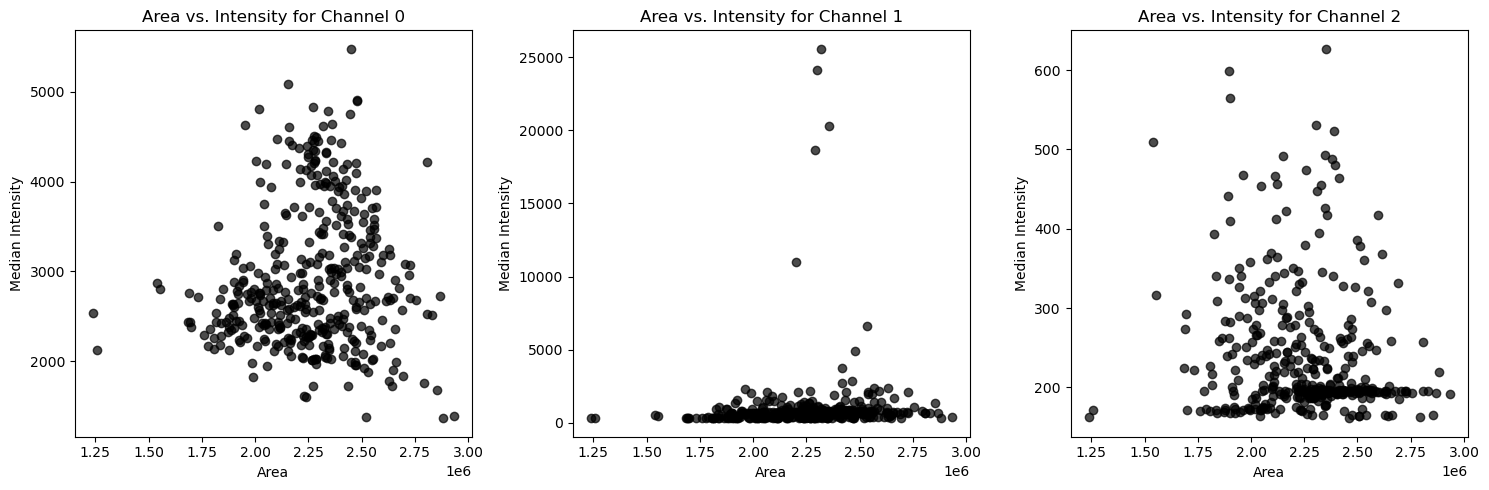

In [219]:
# Plot area vs  intensity for each channel for the true background only (optional)

# Determine the number of channels from the DataFrame column names
# Determine the number of channels from the DataFrame by examining the unique values in the 'channel' column
num_channels = bk_df['channel'].max() + 1  # Assuming channel numbers start from 0

# Set up the figure with subplots arranged side by side
fig, axes = plt.subplots(1, num_channels, figsize=(15, 5))  # Adjust total width and height as needed

if num_channels == 1:  # If there's only one channel, make sure 'axes' is iterable
    axes = [axes]

# Plot each channel's intensity against the area
for idx in range(num_channels):
    current_df = bk_df[bk_df['channel'] == idx]
    ax = axes[idx]
    ax.scatter(current_df['area'], current_df['median_intensity'], color='black', alpha=0.7)
    ax.set_title(f'Area vs. Intensity for Channel {idx}')
    ax.set_xlabel('Area')
    ax.set_ylabel('Median Intensity')

# Ensure the layout is organized to prevent overlap of plot elements
plt.tight_layout()
plt.show()

In [221]:
# CHUNK 4 #

# Extract a set of metrics for each ROI in the image-mask pair
# using the measureROIs() function

from get_roi_metrics import measureROIs

# Set up logging for debugging and progress tracking
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Prepare to store ROI metrics
all_roi_metrics = {}

# Function to process each image and mask pair
def process_image_data(task):
    img_index, mask_index, experiment = task
    image = all_experiments_data[experiment]['all_images']['image'][img_index]
    mask = all_experiments_data[experiment]['all_images']['mask_n'][mask_index]
    return experiment, img_index, measureROIs((img_index, image, mask), subtract_background=False)

# Execute processing in parallel for each experiment in all_experiments_data
if __name__ == '__main__':
    with ThreadPoolExecutor(max_workers=4) as executor:
        # Create tasks with experiment information based on matched indices in each experiment
        tasks = [(img_index, mask_index, experiment) 
                 for experiment, data in all_experiments_data.items() 
                 for img_index, mask_index in data["matched_indices"]]

        # Process tasks in parallel
        results = list(executor.map(process_image_data, tasks))

        # Store the results in the dictionary
        for result in results:
            experiment, img_index, roi_metrics = result
            # Store metrics by experiment and image index
            if experiment not in all_roi_metrics:
                all_roi_metrics[experiment] = {}
            all_roi_metrics[experiment][f'Image {img_index}'] = roi_metrics

    logging.info("Metrics extraction complete for all ROIs across all matched images, no background subtraction.")

2024-11-06 11:39:30,761 - INFO - Metrics extraction complete for all ROIs across all matched images, no background subtraction.


In [223]:
# CHUNK 4.2 #

# Do the same as above, but doing background subtraction

from get_roi_metrics import measureROIs

# Set up logging for debugging and progress tracking
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Prepare to store ROI metrics
bs_roi_metrics = {}

# Function to process each image and mask pair
# Function to process each image and mask pair
def process_image_data(task):
    img_index, mask_index, experiment = task
    image = all_experiments_data[experiment]['all_images']['image'][img_index]
    mask = all_experiments_data[experiment]['all_images']['mask_n'][mask_index]
    return experiment, img_index, measureROIs((img_index, image, mask), subtract_background = True)

# Execute processing in parallel for each experiment in all_experiments_data
if __name__ == '__main__':
    with ThreadPoolExecutor(max_workers=4) as executor:
        # Create tasks with experiment information based on matched indices in each experiment
        tasks = [(img_index, mask_index, experiment) 
                 for experiment, data in all_experiments_data.items() 
                 for img_index, mask_index in data["matched_indices"]]

        # Process tasks in parallel
        results = list(executor.map(process_image_data, tasks))

        # Store the results in the dictionary
        for result in results:
            experiment, img_index, roi_metrics = result
            # Store metrics by experiment and image index
            if experiment not in bs_roi_metrics:
                bs_roi_metrics[experiment] = {}
            bs_roi_metrics[experiment][f'Image {img_index}'] = roi_metrics
            
    logging.info("Metrics extraction complete for all ROIs across all matched images, with background subtraction.")

2024-11-06 12:11:25,901 - INFO - Metrics extraction complete for all ROIs across all matched images, with background subtraction.


In [225]:
# CHUNK 5 #

# Turn the all_roi_metrics and the bs_roi_metrics dictionaries into Pandas data frames for easier manipulation

# List to hold each row's data
data_rows = []

# Iterate through each level of the nested dictionary to extract data
# for each channel of each ROI in each image
for experiment, images in all_roi_metrics.items():
    for image_key, rois in images.items():
        image_index = int(image_key.split()[1])  # Extract image index
        file_name = all_experiments_data[experiment]['base_names']['image'][image_index]  # Get the file name from base names
        
        # Unpack rois tuple into roi_key and channels dictionary
        roi_key, channels_dict = rois  # Unpacking the tuple

        for roi_key, channels in channels_dict.items():  # Using roi_key instead of region_label
            for channel_label, metrics in channels.items():
                # Create a dictionary for each row of data 
                # including experiment, image, ROI, channel, and metrics
                row_data = {
                    "experiment": experiment,
                    "image_index": image_index,
                    "filename": file_name,
                    "ROI_index": roi_key,  # Use roi_key as the unique identifier for each ROI
                    "channel": int(channel_label.split()[1])  # Convert 'Channel X' to integer X
                }

                # Add each metric in metrics to row_data
                for metric_name, metric_value in metrics.items():
                    row_data[metric_name] = metric_value

                # Append each row_data dictionary to the data_rows list
                data_rows.append(row_data)

# Convert the list of dictionaries to a DataFrame
metrics_df = pd.DataFrame(data_rows)

# List to hold each row's data
data_rows = []

# Iterate through each level of the nested dictionary to extract data
# for each channel of each ROI in each image
for experiment, images in bs_roi_metrics.items():
    for image_key, rois in images.items():
        image_index = int(image_key.split()[1])  # Extract image index
        file_name = all_experiments_data[experiment]['base_names']['image'][image_index]  # Get the file name from base names
        
        # Unpack rois tuple into roi_key and channels dictionary
        roi_key, channels_dict = rois  # Unpacking the tuple

        for roi_key, channels in channels_dict.items():  # Using roi_key instead of region_label
            for channel_label, metrics in channels.items():
                # Create a dictionary for each row of data 
                # including experiment, image, ROI, channel, and metrics
                row_data = {
                    "experiment": experiment,
                    "image_index": image_index,
                    "filename": file_name,
                    "ROI_index": roi_key,  # Use roi_key as the unique identifier for each ROI
                    "channel": int(channel_label.split()[1])  # Convert 'Channel X' to integer X
                }

                # Add each metric in metrics to row_data
                for metric_name, metric_value in metrics.items():
                    row_data[metric_name] = metric_value

                # Append each row_data dictionary to the data_rows list
                data_rows.append(row_data)

# Convert the list of dictionaries to a DataFrame
metricsBS_df = pd.DataFrame(data_rows)

In [101]:
# Display the first few rows of the DataFrame to verify it's correct
print(metrics_df.head())
#print(metrics_df['channel'].unique())

          experiment  image_index  \
0  08052024_pDIMMERs            0   
1  08052024_pDIMMERs            0   
2  08052024_pDIMMERs            0   
3  08052024_pDIMMERs            0   
4  08052024_pDIMMERs            0   

                                            filename  ROI_index  channel  \
0  05082024_pDIMMERs_pDIMMER_EGFP_TLP1c_miR-Lx2_m...          1        0   
1  05082024_pDIMMERs_pDIMMER_EGFP_TLP1c_miR-Lx2_m...          1        1   
2  05082024_pDIMMERs_pDIMMER_EGFP_TLP1c_miR-Lx2_m...          1        2   
3  05082024_pDIMMERs_pDIMMER_EGFP_TLP1c_miR-Lx2_m...          2        0   
4  05082024_pDIMMERs_pDIMMER_EGFP_TLP1c_miR-Lx2_m...          2        1   

    area          avg  median         std  maxima  minima  
0  17382  3302.437809  3106.0  645.590364    7195    2037  
1  17382   324.945173   324.0   17.322110     488     262  
2  17382   365.123979   351.0   55.899538     724     251  
3  13111  3742.484860  3711.0  587.373725    5450    2427  
4  13111   301.69498

In [103]:
print(bk_df.head())

          experiment  image_index  mask_index  channel  avg_intensity  \
0  08052024_pDIMMERs            0          31        0    2435.204452   
1  08052024_pDIMMERs            0          31        1     370.483366   
2  08052024_pDIMMERs            0          31        2     354.618821   
3  08052024_pDIMMERs            1           5        0    2359.435582   
4  08052024_pDIMMERs            1           5        1    3632.672533   

   median_intensity     area  
0            2273.0  2238193  
1             349.0  2238193  
2             212.0  2238193  
3            1990.0  2661623  
4            1687.0  2661623  


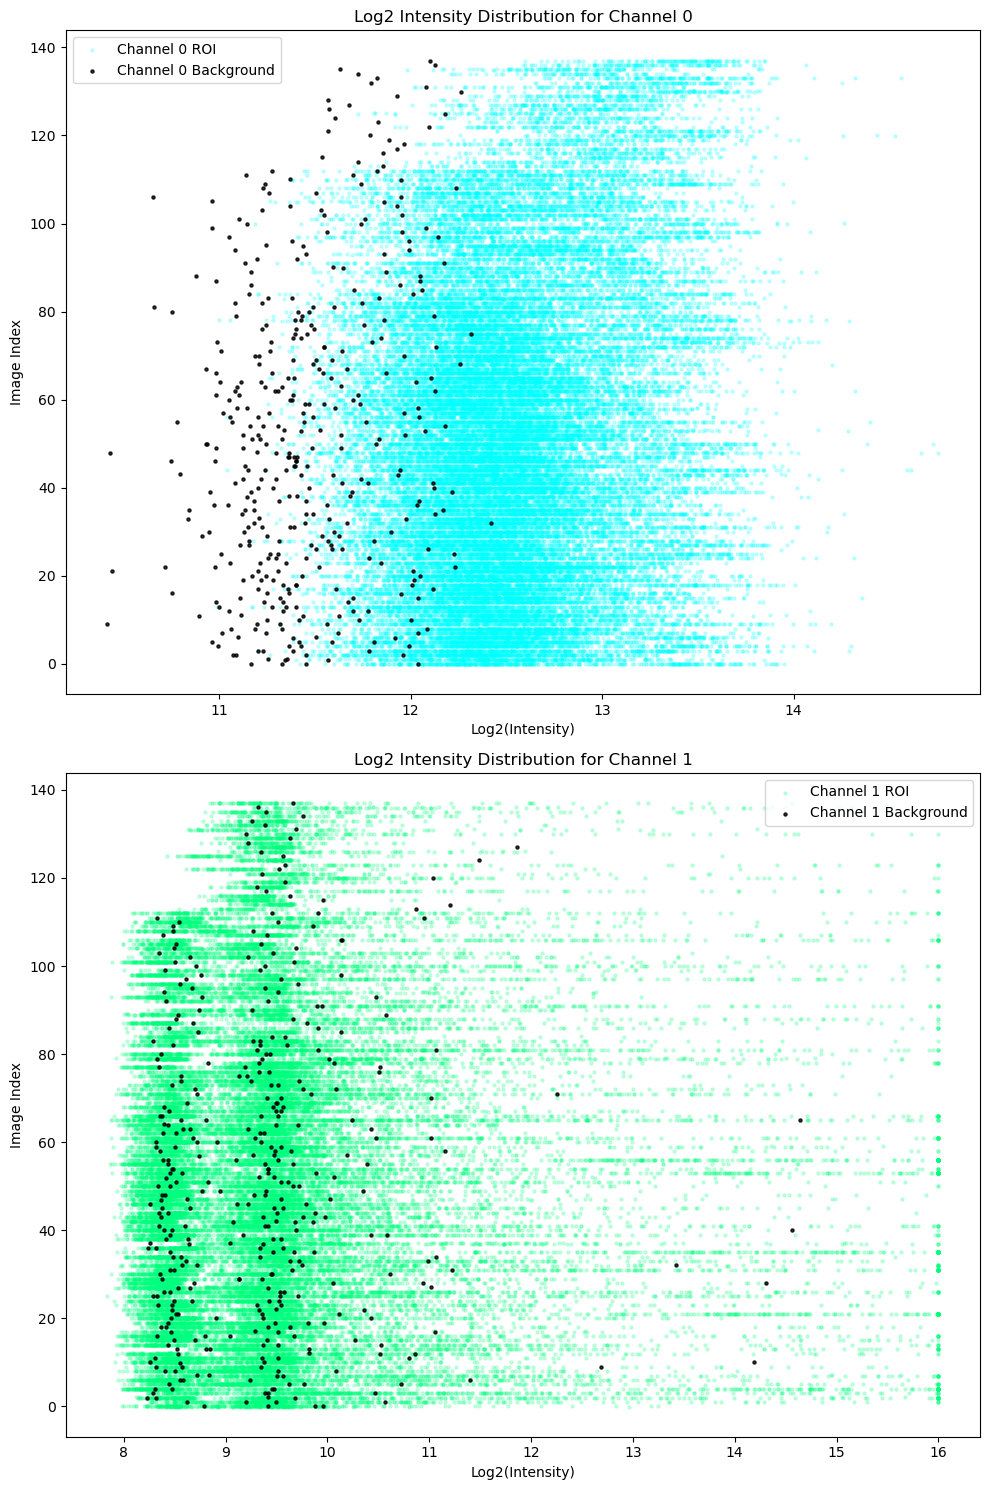

In [227]:
# Plot the background values over the nuclear values to assess if they are in the expected range:

# Define the colors for each channel
# channel_colors = {0: 'cyan', 1: 'springgreen', 2: 'magenta'}
channel_colors = {0: 'cyan', 1: 'springgreen'}

# Setup the figure
fig, ax = plt.subplots(2, 1, figsize=(10, 15))  # Wide plot

def add_jitter(values, jitter_strength=0.03):
    jitter = np.random.uniform(-jitter_strength, jitter_strength, size=len(values))
    return values + jitter

# Plot data for each channel
for channel, ax in enumerate(ax):
    # Get data for the current channel
    # ROI data
    roi_data = metrics_df[metrics_df['channel'] == channel]
    roi_log2_data = np.log2(roi_data['median'] + 1)  # Log2 transform
    roi_image_indices = add_jitter(roi_data['image_index'])  # Add jitter to image index

    # Background data
    bk_data = bk_df[bk_df['channel'] == channel]
    bk_log2_data = np.log2(bk_data['median_intensity'] + 1)  # Log2 transform
    bk_image_indices = add_jitter(bk_data['mask_index'])  # Add jitter to image index


    # Scatter plots
    # Plot ROI data
    ax.scatter(roi_log2_data, roi_image_indices, 
               color=channel_colors[channel], 
               s=5,
               alpha=0.2, 
               label=f'Channel {channel} ROI')
    # Plot Background data
    ax.scatter(bk_log2_data, bk_image_indices, 
               color='black', 
               s=5,
               alpha=0.8, 
               label=f'Channel {channel} Background')

    # Set titles and labels
    ax.set_title(f'Log2 Intensity Distribution for Channel {channel}')
    ax.set_xlabel('Log2(Intensity)')
    ax.set_ylabel('Image Index')
    ax.legend()

# Adjust layout
plt.tight_layout()
plt.show()

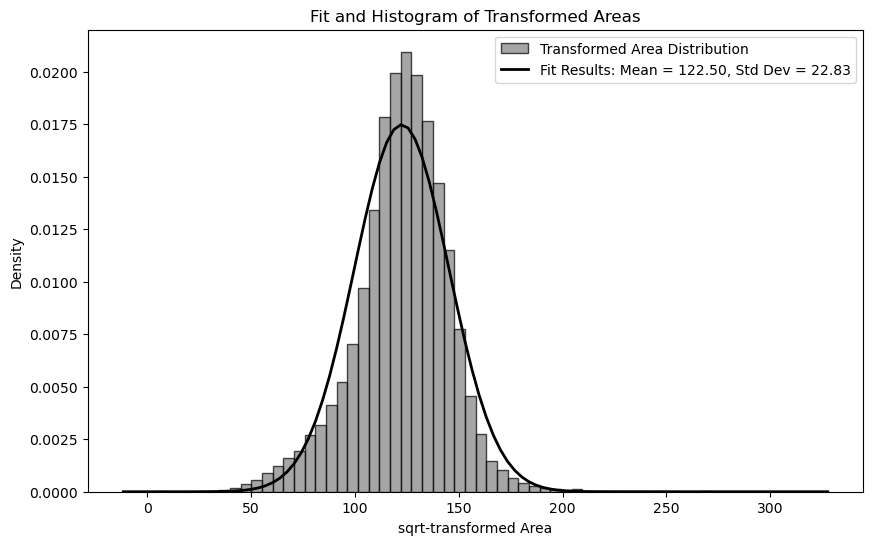

In [229]:
# Plot the distribution of ROI areas in the raw data

# Set the transformation (log or sqrt) of the data you want to visualize
tx = 'sqrt'

# Define the directory to save the plot
plot_dir = os.path.join(parent_directory, experiment, "py-plots/outlier_removal")
os.makedirs(plot_dir, exist_ok = True)

# Collect all ROI areas directly from the DataFrame
all_areas = metrics_df['area'].values

# Apply the transformation (log or sqrt)
if tx == 'log':
    tx_areas = np.log(all_areas + 1)  # Added 1 to avoid log(0)
elif tx == 'sqrt':
    tx_areas = np.sqrt(all_areas)
else:
    raise ValueError("Transformation should be either 'log' or 'sqrt'.")

# Fit a normal distribution to the transformed areas
mean, std_dev = norm.fit(tx_areas)

# Generate histogram of the transformed areas
plt.figure(figsize=(10, 6))
n, bins, patches = plt.hist(tx_areas, 
                            bins=60, 
                            color='gray', 
                            edgecolor='black', 
                            linewidth=1, 
                            alpha=0.7, 
                            label='Transformed Area Distribution', 
                            density=True)
plt.xlabel(f'{tx}-transformed Area')
plt.ylabel('Density')

# Generate the normal distribution curve
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mean, std_dev)
plt.plot(x, p, 'k', linewidth=2, label=f'Fit Results: Mean = {mean:.2f}, Std Dev = {std_dev:.2f}')
plt.title('Fit and Histogram of Transformed Areas')
plt.legend()

# Save the plot to disk as a .png file
plot_filename = 'area_distr_original.png'  # Replace with your desired file name
plt.savefig(f"{plot_dir}/{plot_filename}", format='png')  # Change format to 'tif' if needed

# Show the plot on the console
plt.show()

plt.close()  # Close the plot to free memory

In [231]:
# CHUNK 6 # 

# Remove values outside the number of SD that the user defines 
# for the log or sqrt-transformed data, as above
# (2*SD seems generally reasonable for this data)
# using the outliersOut function found in outliers_removal.py

from outliers_removal import outliersOut

sd_cutoff = 2
tx = "sqrt"

filtr_metrics_df, thresholds = outliersOut(metrics_df, sd_filter = sd_cutoff, transformation = tx)

# Print the thresholds to verify them
print("Calculated thresholds:")
print(f"Mean: {thresholds[0]}, Std Dev: {thresholds[1]}")
print(f"Lower Threshold: {thresholds[2]}, Upper Threshold: {thresholds[3]}")

# Optionally, display some of the filtered data to inspect the results
# print(filtr_metrics_df.head())

Calculated thresholds:
Mean: 122.50200388933189, Std Dev: 22.834384958316686
Lower Threshold: 76.83323397269851, Upper Threshold: 168.17077380596527


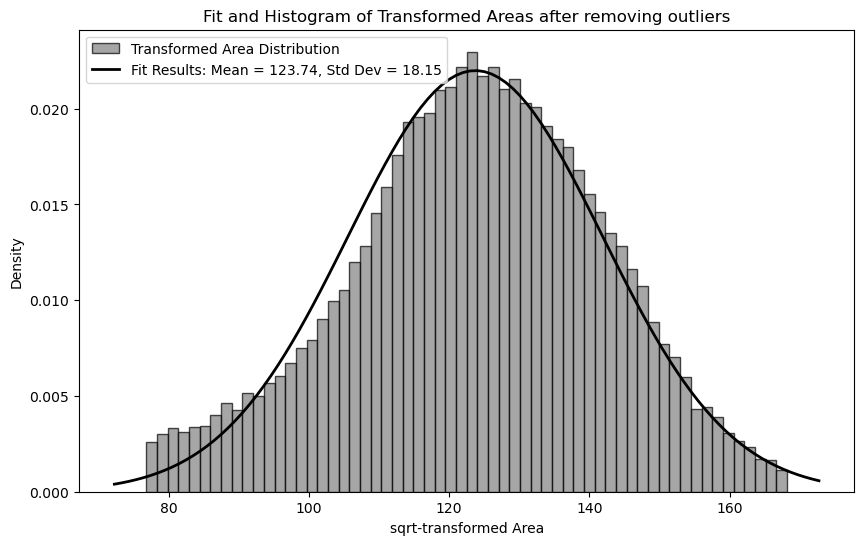

In [233]:
# Plot the distribution of ROI areas in the filtered data

# Set the transformation (log or sqrt) of the data you want to visualize
tx = 'sqrt'

# Define the directory to save the plot
plot_dir = os.path.join(parent_directory, experiment, "py-plots/outlier_removal")
os.makedirs(plot_dir, exist_ok = True)

# Collect all ROI areas directly from the DataFrame
all_areas = filtr_metrics_df['area'].values

# Apply the transformation (log or sqrt)
if tx == 'log':
    tx_areas = np.log(all_areas + 1)  # Added 1 to avoid log(0)
elif tx == 'sqrt':
    tx_areas = np.sqrt(all_areas)
else:
    raise ValueError("Transformation should be either 'log' or 'sqrt'.")

# Fit a normal distribution to the transformed areas
mean, std_dev = norm.fit(tx_areas)

# Generate histogram of the transformed areas
plt.figure(figsize=(10, 6))
n, bins, patches = plt.hist(tx_areas, 
                            bins=60, 
                            color='gray', 
                            edgecolor='black', 
                            linewidth=1, 
                            alpha=0.7, 
                            label='Transformed Area Distribution', 
                            density=True)
plt.xlabel(f'{tx}-transformed Area')
plt.ylabel('Density')

# Generate the normal distribution curve
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mean, std_dev)
plt.plot(x, p, 'k', linewidth=2, label=f'Fit Results: Mean = {mean:.2f}, Std Dev = {std_dev:.2f}')
plt.title('Fit and Histogram of Transformed Areas after removing outliers')
plt.legend()

# Save the plot to disk as a .png file
plot_filename = 'area_distr_no-outliers.png'  # Replace with your desired file name
plt.savefig(f"{plot_dir}/{plot_filename}", format='png')  # Change format to 'tif' if needed

# Show the plot on the console
plt.show()

plt.close()  # Close the plot to free memory

In [113]:
# Replace these with the indices of the image, ROI, and channel you want to inspect
image_index = 5  # First image
roi_index = 9   # ROI with ID 9
channel_index = 0  # First channel

image_file = image_base_names[image_index]
image_key = f"Image {image_index}"
roi_metrics = all_roi_metrics.get(image_key, {})
roi_channel_metrics = roi_metrics.get(roi_index, {}).get(f'Channel {channel_index}', {})

print(f"Metrics for Image {image_index}, ({image_file}), ROI {roi_index}, Channel {channel_index}:")
for metric, value in roi_channel_metrics.items():
    print(f"  {metric}: {value:.2f}")

Metrics for Image 5, (10072024_pDIMMERs_pDIMMER_10_1_MMStack_Pos1_MIP), ROI 9, Channel 0:


In [115]:
print(metrics_df.head())

          experiment  image_index  \
0  08052024_pDIMMERs            0   
1  08052024_pDIMMERs            0   
2  08052024_pDIMMERs            0   
3  08052024_pDIMMERs            0   
4  08052024_pDIMMERs            0   

                                            filename  ROI_index  channel  \
0  05082024_pDIMMERs_pDIMMER_EGFP_TLP1c_miR-Lx2_m...          1        0   
1  05082024_pDIMMERs_pDIMMER_EGFP_TLP1c_miR-Lx2_m...          1        1   
2  05082024_pDIMMERs_pDIMMER_EGFP_TLP1c_miR-Lx2_m...          1        2   
3  05082024_pDIMMERs_pDIMMER_EGFP_TLP1c_miR-Lx2_m...          2        0   
4  05082024_pDIMMERs_pDIMMER_EGFP_TLP1c_miR-Lx2_m...          2        1   

    area          avg  median         std  maxima  minima     tx_area  
0  17382  3302.437809  3106.0  645.590364    7195    2037  131.840813  
1  17382   324.945173   324.0   17.322110     488     262  131.840813  
2  17382   365.123979   351.0   55.899538     724     251  131.840813  
3  13111  3742.484860  3711.0  5

In [235]:
# Read in the experimental-groups reference files

# Initialize an empty list to store each experiments data frame
exp_groups_list = []

# Loop through each experiment defined at the beginning and read its CSV file
for experiment in experiment_list:
    # Read the CSV file for the current experiment
    exp_group_df = pd.read_csv(os.path.join(parent_directory, experiment, "experimental-groups.csv"))
    
    # Rename the column "experiment_folder" to "experiment"
    exp_group_df.rename(columns={"experiment_folder": "experiment"}, inplace=True)
    
    # Append the DataFrame to the list
    exp_groups_list.append(exp_group_df)

# Combine all DataFrames in the list into a single DataFrame
exp_groups = pd.concat(exp_groups_list, ignore_index=True)

In [237]:
# CHUNK 7
# Combine the metrics_df data frame with the metadata contained in exp_groups, 
# so that we can group observations by experiment

# First, modify filename in exp_groups so that it matches that of metrics_df
# (instead of ending in ".ome.tif", it must end in "_MIP.tif")
exp_groups['filename'] = exp_groups['filename'].str.replace('.ome.tif', '_MIP')

# Then, combine both data frames with a left join using Pandas' merge() function
combined_df = pd.merge(metrics_df, exp_groups, on = ["filename", "experiment"], how = "inner")

In [239]:
# Do a quick QC of data frames pre-and post-merge, to ensure no rows were lost in the process

# Look at unique entries in both
unique_metrics_filenames = metrics_df['filename'].nunique()
print(f"Number of unique filenames in metrics_df: {unique_metrics_filenames}")
unique_combined_filenames = combined_df['filename'].nunique()
print(f"Number of unique filenames in combined_df: {unique_combined_filenames}")

# Total number of entries:
print(f"Total entries in metrics_df: {metrics_df.shape[0]}")
print(f"Total entries in combined_df: {combined_df.shape[0]}")

# And unique instances of "plasmid"
unique_plasmids = exp_groups['plasmid'].nunique()
unique_combined_plasmids = combined_df['plasmid'].nunique()
print(f"Unique plasmids in experiment: {unique_plasmids}")
print(f"Unique plasmids in combined_df: {unique_plasmids}")

Number of unique filenames in metrics_df: 402
Number of unique filenames in combined_df: 402
Total entries in metrics_df: 147868
Total entries in combined_df: 147868
Unique plasmids in experiment: 18
Unique plasmids in combined_df: 18


In [241]:
# Read plasmid reference file
plasmid_ref = pd.read_csv(os.path.join(repo_directory, 'reference/', 'plasmid_ref_pDIMMERs.csv'))
print(plasmid_ref['plasmid'].unique())
print(plasmid_ref.head())

['pDIMMER_NT-EGFP_TLP1c_no-miR' 'pDIMMER_NT-EGFP_TLP1c_miR-Lx4_synmiR'
 'pDIMMER_NT-EGFP_TLP1c_miR-Lx4_miR-L'
 'pDIMMER_NT-EGFP_TLP1c_miR-Lx2_miR-L' 'pPGK_NT-EGFP_TLP1c'
 'pPGK_NT-EGFP_TLP1c_miR-Lx4_miR-L' 'pCMV_NT-EGFP_TLP1c'
 'pCMV_NT-EGFP_TLP1c_miR-Lx4_miR-L' 'pEC_NT-EGFP_TLP1c'
 'pEC_NT-EGFP_TLP1c_miR-Lx4_miR-L'
 'pDIMMER_NT-EGFP_TLP1c_mirLx4_mRuby_miR-L'
 'pDIMMER_NT-EGFP_TLP1c_mirLx4_mRuby_synmiR' 'none']
                                plasmid promoter   miRNA target_sites  \
0          pDIMMER_NT-EGFP_TLP1c_no-miR     pECM  no_miR            0   
1  pDIMMER_NT-EGFP_TLP1c_miR-Lx4_synmiR     pECM  synmiR            4   
2   pDIMMER_NT-EGFP_TLP1c_miR-Lx4_miR-L     pECM   miR-L            4   
3   pDIMMER_NT-EGFP_TLP1c_miR-Lx2_miR-L     pECM   miR-L            2   
4                    pPGK_NT-EGFP_TLP1c     pPGK  no_miR            0   

  left_transcript              right_transcript  
0           mRuby                 NT-EGFP_TLP1c  
1           mRuby  NT-EGFP_TLP1c_miR-Lx4_synmi

In [243]:
# Incorporate plasmid information into combined_df
# filtering for plasmids contained in the plasmid_ref data frame only
# MAKE SURE your names match so you don't drop data
combined_df = pd.merge(plasmid_ref, combined_df, on = "plasmid", how = "left")
#print(combined_df.head())

In [245]:
# Save the combined data frame as a CSV file
combined_df.to_csv(os.path.join(repo_directory, "pDIMMERS_combined.csv"), index = False)

In [247]:
print(combined_df['plasmid'].unique())

['pDIMMER_NT-EGFP_TLP1c_no-miR' 'pDIMMER_NT-EGFP_TLP1c_miR-Lx4_synmiR'
 'pDIMMER_NT-EGFP_TLP1c_miR-Lx4_miR-L'
 'pDIMMER_NT-EGFP_TLP1c_miR-Lx2_miR-L' 'pPGK_NT-EGFP_TLP1c'
 'pPGK_NT-EGFP_TLP1c_miR-Lx4_miR-L' 'pCMV_NT-EGFP_TLP1c'
 'pCMV_NT-EGFP_TLP1c_miR-Lx4_miR-L' 'pEC_NT-EGFP_TLP1c'
 'pEC_NT-EGFP_TLP1c_miR-Lx4_miR-L'
 'pDIMMER_NT-EGFP_TLP1c_mirLx4_mRuby_miR-L'
 'pDIMMER_NT-EGFP_TLP1c_mirLx4_mRuby_synmiR' 'none']


In [73]:
# Read in CSV with all data if not running from the top
combined_df = pd.read_csv(os.path.join(repo_directory, "pDIMMERS_combined.csv"))
#print(combined_df.head())

/var/folders/ms/knsq1kqj0cbgqnbmt1rng0yw0000gr/T/ipykernel_2451/2309088329.py:2: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.


In [249]:
# Prepare to plot the data obtained above using plotnine

# Choose the metric to plot:
my_metric = 'median'
x_label = "Median Intensity"

# Calculate the log10 of the chosen metric
combined_df['log10_median'] = np.log10(combined_df[my_metric] + 1)  # Adding 1 to avoid log(0)

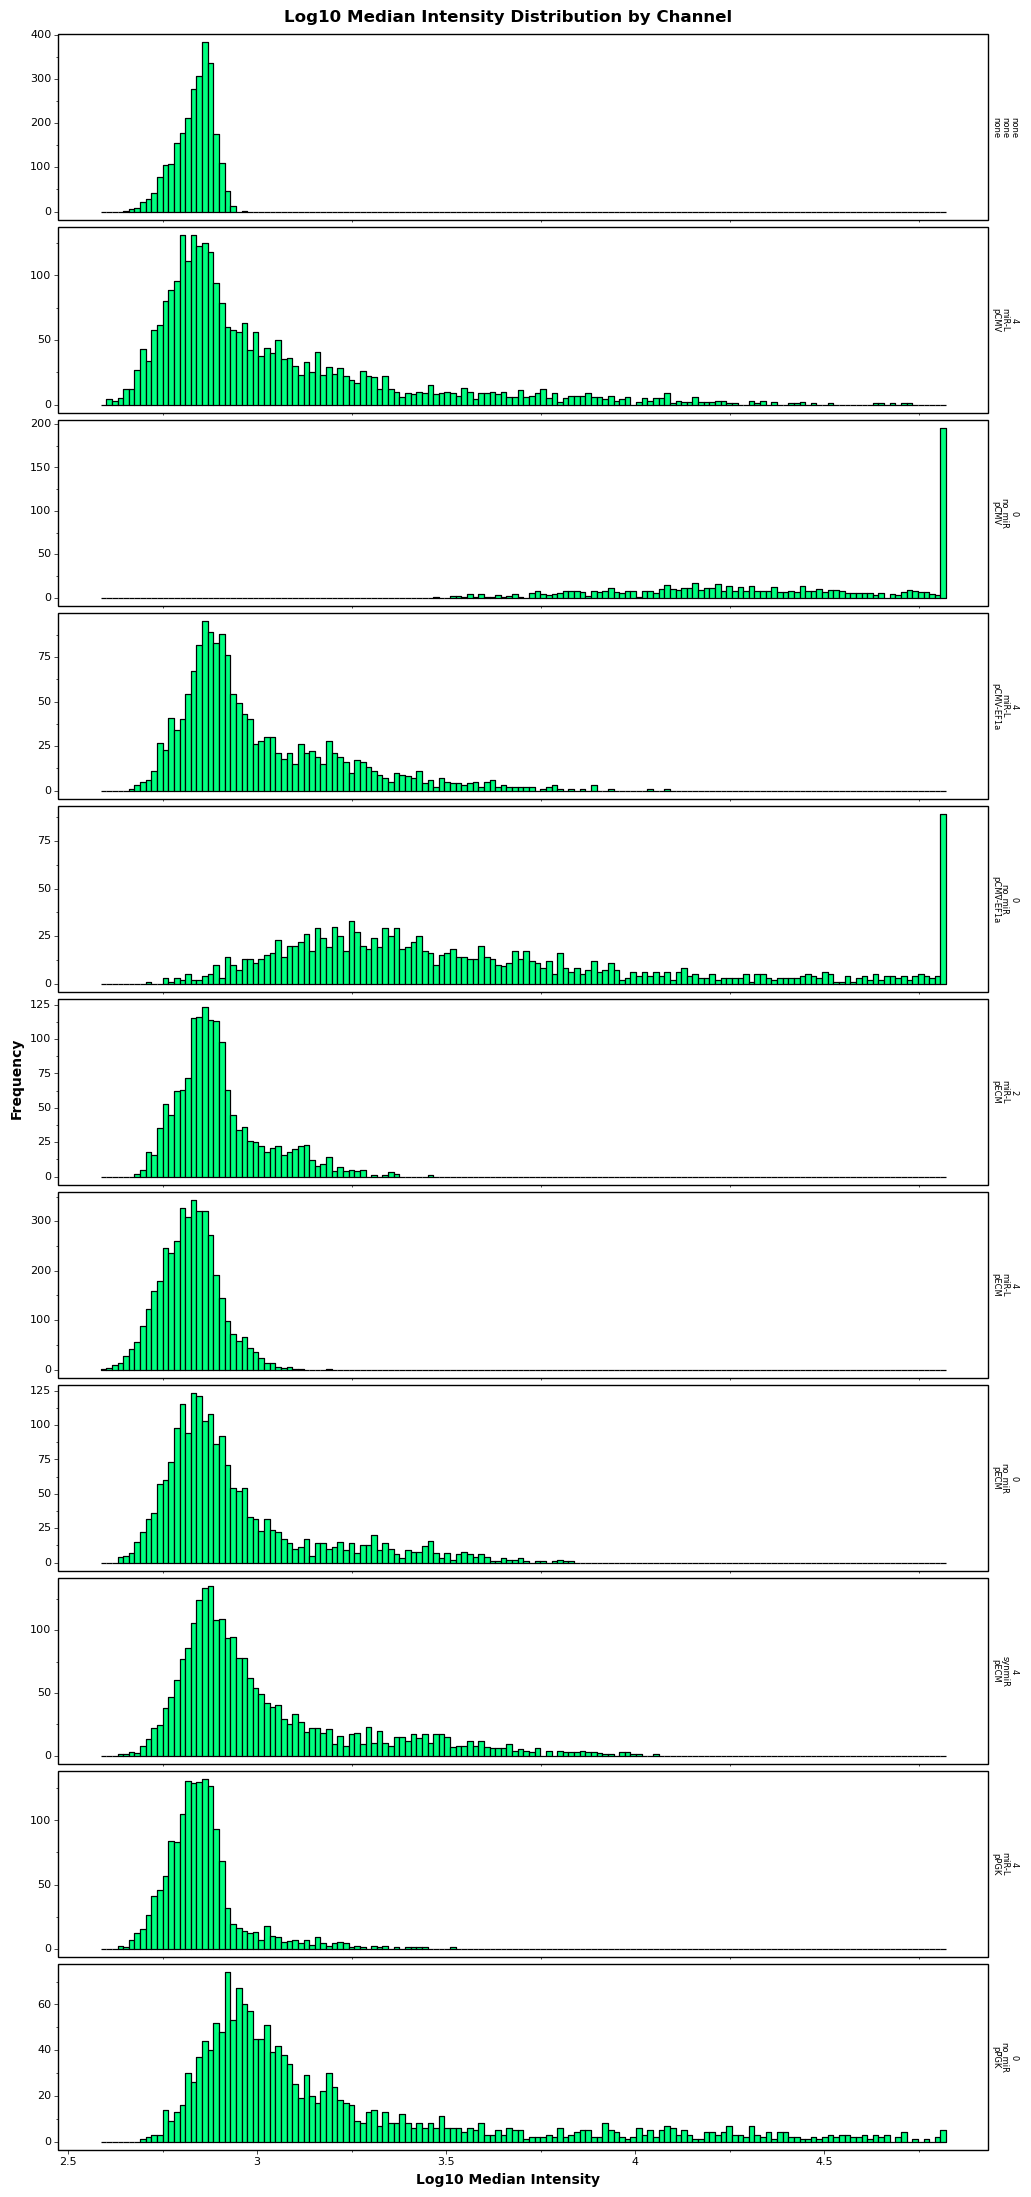

In [263]:
# Make histograms of GFP levels
# Plot the values of Channel 0 (Hoechst) and Channel 1 (GFP) as histograms for each plasmid

# Assign colors to each channel
channel_colors = {0: 'blue', 1: 'springgreen', 2: 'magenta'}

# Define some list of values to filter by
my_plasmids = ['pDIMMER_NT-EGFP_TLP1c_no-miR', 'pDIMMER_NT-EGFP_TLP1c_miR-Lx4_synmiR',
               'pDIMMER_NT-EGFP_TLP1c_miR-Lx4_miR-L', 'pDIMMER_NT-EGFP_TLP1c_miR-Lx2_miR-L', 
               'pPGK_NT-EGFP_TLP1c', 'pDIMMER_NT-EGFP_TLP1c_mirLx4_mRuby_miR-L',
               'pDIMMER_NT-EGFP_TLP1c_mirLx4_mRuby_synmiR', 'none']
aug_experiments = ['08052024_pDIMMERs', '08122024_pDIMMERs']
oct_experiments = ['10032024_pDIMMERs', '10072024_pDIMMERs']

# Subset the data to plot
my_data = combined_df[(combined_df['channel'].isin([1])) & 
                        #(combined_df['plasmid'].isin(my_plasmids)) & 
                        (combined_df['experiment'].isin(oct_experiments))]

# Define plot using plotnine
plot = (
    p9.ggplot(data = my_data) + 
    p9.aes(x = 'log10_median', fill = 'factor(channel)') +  # factor() to treat channel as categorical
    p9.geom_histogram(bins = 150, color = 'black') +
    p9.facet_grid('promoter + miRNA + target_sites ~ ', scales = 'free_y') +  # Create separate plots for each channel
    #p9.scale_x_continuous(limits = (combined_df['log10_median'].min(), 
    #                                combined_df['log10_median'].max())) +
    p9.scale_fill_manual(values = channel_colors) +
    p9.labs(title = 'Log10 Median Intensity Distribution by Channel',
            x = 'Log10 Median Intensity',
            y = 'Frequency') +
    p9.theme_bw() + 
    p9.theme(figure_size = (12, 12), # Adjust figure size
             aspect_ratio = 1/5,
             subplots_adjust = {'wspace': 0.20},  # Adjust space between plots
             legend_position = 'none',  # Hide legend if desired
             panel_grid = p9.element_blank(), 
             strip_background = p9.element_blank(), 
             panel_border = p9.element_rect(color = 'black', linewidth = 1), 
             axis_ticks = p9.element_line(color = 'black', linewidth = 0.5), 
             plot_title = p9.element_text(size = 12, color = 'black', face = 'bold'),
             axis_text = p9.element_text(size = 8, color = 'black'), 
             axis_title = p9.element_text(size = 10, color = 'black', face = 'bold'), 
             legend_text = p9.element_text(size = 8, color = 'black'), 
             legend_title = p9.element_text(size = 10, color = 'black', face = 'bold'), 
             strip_text = p9.element_text(size = 6, color = 'black'))
)

# Print the plot
print(plot)

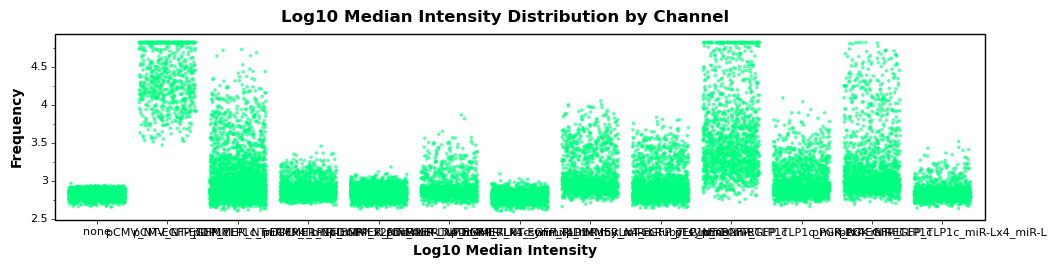

In [271]:
# Plot the same data as above but as boxplots and scatterplots
# Assign colors to each channel
channel_colors = {0: 'blue', 1: 'springgreen', 2: 'magenta'}

# Define some list of values to filter by
my_plasmids = ['pDIMMER_NT-EGFP_TLP1c_no-miR', 'pDIMMER_NT-EGFP_TLP1c_miR-Lx4_synmiR',
               'pDIMMER_NT-EGFP_TLP1c_miR-Lx4_miR-L', 'pDIMMER_NT-EGFP_TLP1c_miR-Lx2_miR-L', 
               'pPGK_NT-EGFP_TLP1c', 'pDIMMER_NT-EGFP_TLP1c_mirLx4_mRuby_miR-L',
               'pDIMMER_NT-EGFP_TLP1c_mirLx4_mRuby_synmiR', 'none']
aug_experiments = ['08052024_pDIMMERs', '08122024_pDIMMERs']
oct_experiments = ['10032024_pDIMMERs', '10072024_pDIMMERs']

# Subset the data to plot
my_data = combined_df[(combined_df['channel'].isin([1])) & 
                        #(combined_df['plasmid'].isin(my_plasmids)) & 
                        (combined_df['experiment'].isin(oct_experiments))]

# Define plot using plotnine
plot = (
    p9.ggplot(data = my_data) + 
    p9.aes(x = 'plasmid', y = 'log10_median', color = 'factor(channel)') +  # factor() to treat channel as categorical
    p9.geom_jitter(size = 0.5, alpha = 0.5) +
    #p9.facet_grid('promoter + miRNA + target_sites ~ ', scales = 'free_y') +  # Create separate plots for each channel
    p9.scale_color_manual(values = channel_colors) +
    p9.labs(title = 'Log10 Median Intensity Distribution by Channel',
            x = 'Log10 Median Intensity',
            y = 'Frequency') +
    p9.theme_bw() + 
    p9.theme(figure_size = (12, 12), # Adjust figure size
             aspect_ratio = 1/5,
             subplots_adjust = {'wspace': 0.20},  # Adjust space between plots
             legend_position = 'none',  # Hide legend if desired
             panel_grid = p9.element_blank(), 
             strip_background = p9.element_blank(), 
             panel_border = p9.element_rect(color = 'black', linewidth = 1), 
             axis_ticks = p9.element_line(color = 'black', linewidth = 0.5), 
             plot_title = p9.element_text(size = 12, color = 'black', face = 'bold'),
             axis_text = p9.element_text(size = 8, color = 'black'), 
             axis_title = p9.element_text(size = 10, color = 'black', face = 'bold'), 
             legend_text = p9.element_text(size = 8, color = 'black'), 
             legend_title = p9.element_text(size = 10, color = 'black', face = 'bold'), 
             strip_text = p9.element_text(size = 6, color = 'black'))
)

# Print the plot
print(plot)

In [79]:
# Read a small CSV with some reference measurements (manual) 
# for negative cells, cells with spots and too bright cells
ref_int = pd.read_csv(os.path.join(repo_directory, "reference/", "intensity_reference.csv"))
ref_int['log10_median'] = np.log10(ref_int["median"])

/Users/nestor/anaconda3/envs/python-img/lib/python3.11/site-packages/plotnine/layer.py:411: PlotnineWarning: geom_histogram : Removed 18 rows containing missing values.


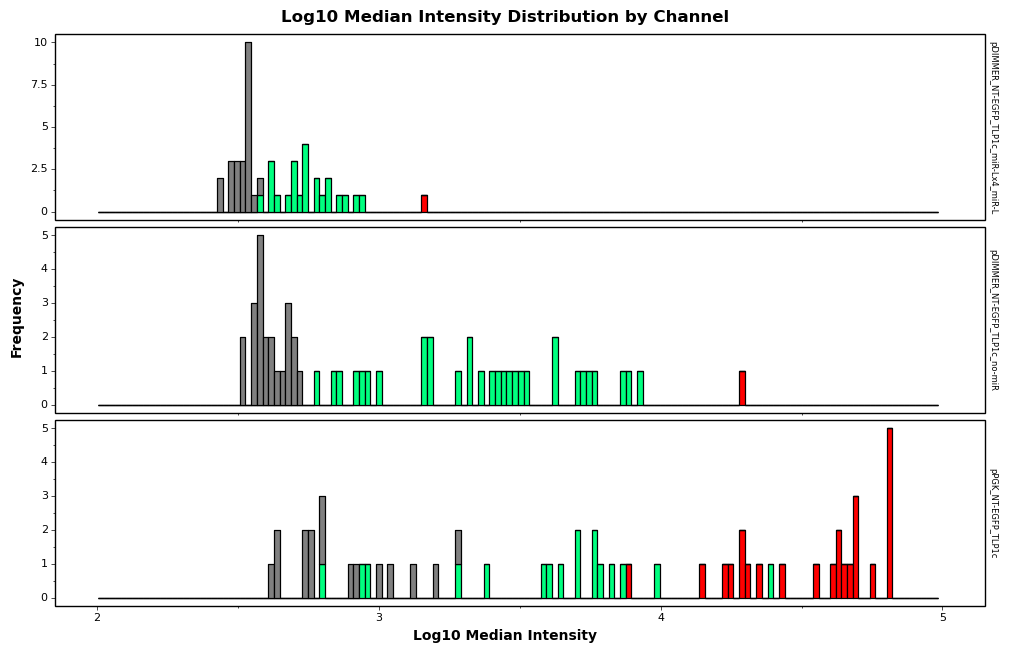

In [19]:
# Plot a histogram as above for this reference data
# Define plot using plotnine
buckolors = {"negative": 'gray', 
             "spots": 'springgreen', 
             "too_bright": 'red'}
plot = (
    p9.ggplot(data = ref_int) + 
    p9.aes(x = 'log10_median', fill = 'factor(bucket)') +  # factor() to treat channel as categorical
    p9.geom_histogram(bins = 150, color = 'black') +
    p9.facet_grid('plasmid ~ ', scales = 'free_y') +  # Create separate plots for each channel
    p9.scale_x_continuous(limits = (2, 5)) +
    p9.scale_fill_manual(values = buckolors) +
    p9.labs(title = 'Log10 Median Intensity Distribution by Channel',
            x = 'Log10 Median Intensity',
            y = 'Frequency') +
    p9.theme_bw() + 
    p9.theme(figure_size = (12, 12), # Adjust figure size
             aspect_ratio = 1/5,
             subplots_adjust = {'wspace': 0.20},  # Adjust space between plots
             legend_position = 'none',  # Hide legend if desired
             panel_grid = p9.element_blank(), 
             strip_background = p9.element_blank(), 
             panel_border = p9.element_rect(color = 'black', linewidth = 1), 
             axis_ticks = p9.element_line(color = 'black', linewidth = 0.5), 
             plot_title = p9.element_text(size = 12, color = 'black', face = 'bold'),
             axis_text = p9.element_text(size = 8, color = 'black'), 
             axis_title = p9.element_text(size = 10, color = 'black', face = 'bold'), 
             legend_text = p9.element_text(size = 8, color = 'black'), 
             legend_title = p9.element_text(size = 10, color = 'black', face = 'bold'), 
             strip_text = p9.element_text(size = 6, color = 'black'))
)

# Print the plot
print(plot)

In [81]:
print(combined_df.head())

                        plasmid promoter   miRNA target_sites left_transcript  \
0  pDIMMER_NT-EGFP_TLP1c_no-miR     pECM  no_miR            0           mRuby   
1  pDIMMER_NT-EGFP_TLP1c_no-miR     pECM  no_miR            0           mRuby   
2  pDIMMER_NT-EGFP_TLP1c_no-miR     pECM  no_miR            0           mRuby   
3  pDIMMER_NT-EGFP_TLP1c_no-miR     pECM  no_miR            0           mRuby   
4  pDIMMER_NT-EGFP_TLP1c_no-miR     pECM  no_miR            0           mRuby   

  right_transcript         experiment  image_index  \
0    NT-EGFP_TLP1c  08052024_pDIMMERs            5   
1    NT-EGFP_TLP1c  08052024_pDIMMERs            5   
2    NT-EGFP_TLP1c  08052024_pDIMMERs            5   
3    NT-EGFP_TLP1c  08052024_pDIMMERs            5   
4    NT-EGFP_TLP1c  08052024_pDIMMERs            5   

                                            filename  ROI_index  channel  \
0  05082024_pDIMMERs_pDIMMER_EGFP_TLP1c_no-miR_1_...          1        0   
1  05082024_pDIMMERs_pDIMMER_EGFP_TL

In [253]:
# Pivot the combined data frame to wide format, separating each channel into one variable, 
# to plot as scatterplot

# Extract a subset of columns into a new data frame
wide_df = combined_df[['image_index', 'filename', 'plasmid', 'promoter', 'miRNA', 'target_sites', 
                       'experiment', 'ROI_index', 'channel', 'log10_median']]

# Pivot wide_df to get separate columns for each channel's log10_median
wide_df = wide_df.pivot(
    index = ['image_index', 'filename', 'experiment', 'plasmid', 'promoter', 
             'miRNA', 'target_sites', 'ROI_index'],  # Indices to group by
    columns = 'channel',  # Column to pivot
    values = 'log10_median'  # Values to fill with
).reset_index()

# Rename the pivoted columns to reflect the channel information
wide_df.columns = [f"{col}_log10_median" if isinstance(col, int) else col for col in wide_df.columns]
wide_df.rename(columns = {
    '0_log10_median': 'ch0_log10_median',
    '1_log10_median': 'ch1_log10_median', 
    '2_log10_median': 'ch2_log10_median'
}, inplace = True)

In [203]:
taz_data = pd.read_csv(os.path.join(repo_directory, "pDIMMERs_Tas.csv"))
taz_data.rename(columns = {'within_threshold': 'tx_status_taz'}, inplace = True)

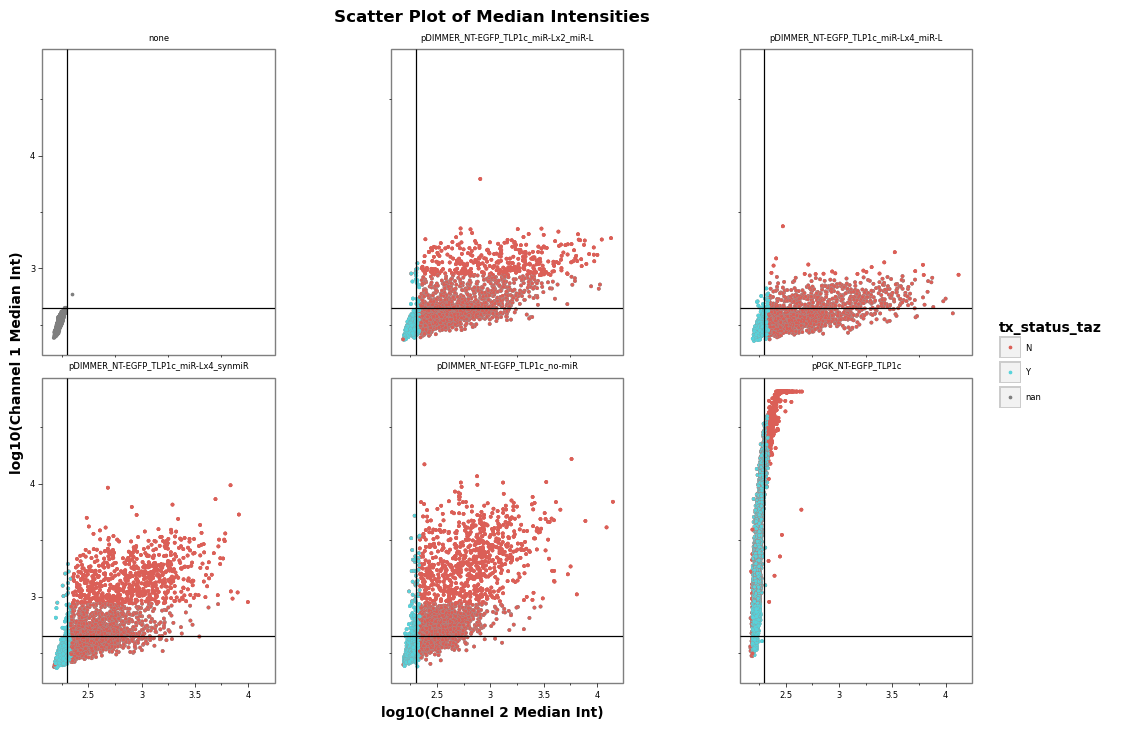

In [273]:
# Scatterplot

# Define some list of values to filter by
my_plasmids = ['pDIMMER_NT-EGFP_TLP1c_no-miR', 'pDIMMER_NT-EGFP_TLP1c_miR-Lx4_synmiR',
               'pDIMMER_NT-EGFP_TLP1c_miR-Lx4_miR-L', 'pDIMMER_NT-EGFP_TLP1c_miR-Lx2_miR-L', 
               'pPGK_NT-EGFP_TLP1c', 'pDIMMER_NT-EGFP_TLP1c_mirLx4_mRuby_miR-L',
               'pDIMMER_NT-EGFP_TLP1c_mirLx4_mRuby_synmiR', 'none']
aug_experiments = ['08052024_pDIMMERs', '08122024_pDIMMERs']
oct_experiments = ['10032024_pDIMMERs', '10072024_pDIMMERs']

my_data = pd.merge(wide_df, 
                   taz_data[['filename', 'ROI_index', 'tx_status_taz']], 
                   on = ["filename", "ROI_index"], how = "left")

my_data = my_data[my_data['experiment'].isin(aug_experiments)]

# Plot Channel 0 vs Channel 1 as a scatter plot to separate clusters
plot = (
    p9.ggplot(data = my_data, 
              mapping = p9.aes(x = 'ch2_log10_median', 
                               y = 'ch1_log10_median', 
                               color = 'tx_status_taz')) +  # Set aesthetic mappings
    p9.geom_point(size = 0.5) +  # Add points for scatter plot
    p9.geom_vline(xintercept = 2.3) +
    p9.geom_hline(yintercept = 2.65) +
    p9.labs(
        title = 'Scatter Plot of Median Intensities',
        x = 'log10(Channel 2 Median Int)',
        y = 'log10(Channel 1 Median Int)'
    ) + 
    p9.facet_wrap(' ~ plasmid') +  # Create separate plots for each channel
    p9.theme_bw() +  # Use a clean theme
    p9.theme(
        figure_size = (12, 6),  # Set the size of the plot
        aspect_ratio = 1,
        subplots_adjust = {'wspace': 0.50},  # Adjust space between plots
        panel_grid = p9.element_blank(),  # Hide grid lines
        #legend_position = 'none',  # Hide legend if desired
        plot_background = p9.element_rect(fill='white'),  # Set background to white
        axis_ticks = p9.element_line(color = 'black', linewidth = 0.5), 
        plot_title = p9.element_text(size = 12, color = 'black', face = 'bold'),
        axis_text = p9.element_text(size = 6, color = 'black'), 
        axis_title = p9.element_text(size = 10, color = 'black', face = 'bold'), 
        legend_text = p9.element_text(size = 6, color = 'black'), 
        legend_title = p9.element_text(size = 10, color = 'black', face = 'bold'), 
        strip_text = p9.element_text(size = 6, color = 'black'), 
        strip_background = p9.element_blank()
    )
)

# Print the plot
print(plot)

In [ ]:
print(combined_df['plasmid'].unique())

In [143]:
# CHUNK 8
# Correct Channel 1 values

# There seems to be some sort of relationship between Channel 1 and Channel 0 that should not be there. 
# I will fit a linear model to the data of untransfected cells, and use the slope to correct Ch1 in all groups

import statsmodels.api as sm

# Filter for untransfected cells
utx = wide_df[wide_df['plasmid'] == 'none']

# Prepare the data for regression
X = utx['ch0_log10_median']  # Independent variable
X = sm.add_constant(X)  # Adds a constant term to the predictor
y = utx['ch1_log10_median']  # Dependent variable

# Fit the linear model
model = sm.OLS(y, X).fit()

# Get the slope (beta coefficient) and intercept
beta, intercept = model.params['ch0_log10_median'], model.params['const']

print("Model coefficients:")
print("Slope (beta):", beta)
print("Intercept:", intercept)

# Calculate the original range of Channel 1 values
or_min = wide_df['ch1_log10_median'].min()
or_max = wide_df['ch1_log10_median'].max()

# Correct CH1 values across the entire wide_df data frame
wide_df['cor_ch1_log10_median'] = wide_df['ch1_log10_median'] - (beta * wide_df['ch0_log10_median'])

# Calculate the range of the corrected values
cor_min = wide_df['cor_ch1_log10_median'].min()
cor_max = wide_df['cor_ch1_log10_median'].max()

# Rescale the corrected values to the original range
wide_df['cor_ch1_log10_median'] = (wide_df['cor_ch1_log10_median'] - cor_min) / (cor_max - cor_min) * (or_max - or_min) + or_min

Model coefficients:
Slope (beta): 0.5526527778761738
Intercept: 0.6320116061519901


In [149]:
# Make a wide_bk_df data frame from bk_df

# Calculate the log2 of the chosen metric
bk_df['log10_median'] = np.log10(bk_df['median_intensity'] + 1)  # Adding 1 to avoid log2(0)

# Extract a subset of columns into a new data frame
wide_bk_df = bk_df[['image_index', 'channel', 'log10_median']]

# Pivot wide_df to get separate columns for each channel's log2_median
wide_bk_df = wide_bk_df.pivot_table(
    index = ['image_index'],  # Indices to group by
    columns = 'channel',  # Column to pivot
    values = 'log10_median',  # Values to fill with
    aggfunc = 'first'  # Using 'first' assuming each group-channel combo has a unique entry
).reset_index()

# Rename the pivoted columns to reflect the channel information
wide_bk_df.columns = [f"{col}_log10_median" if isinstance(col, int) else col for col in wide_bk_df.columns]
wide_bk_df.rename(columns = {
    '0_log10_median': 'ch0_log10_median',
    '1_log10_median': 'ch1_log10_median'
}, inplace = True)

wide_bk_df = pd.merge(wide_bk_df, wide_df[['image_index', 'plasmid']], on = "image_index", how = "left")

In [175]:
print(wide_bk_df.head())

   image_index  ch0_log10_median  ch1_log10_median  2_log10_median  \
0            0           3.35679          2.544068         2.32838   
1            0           3.35679          2.544068         2.32838   
2            0           3.35679          2.544068         2.32838   
3            0           3.35679          2.544068         2.32838   
4            0           3.35679          2.544068         2.32838   

                               plasmid  
0  pDIMMER_NT-EGFP_TLP1c_miR-Lx2_miR-L  
1  pDIMMER_NT-EGFP_TLP1c_miR-Lx2_miR-L  
2  pDIMMER_NT-EGFP_TLP1c_miR-Lx2_miR-L  
3  pDIMMER_NT-EGFP_TLP1c_miR-Lx2_miR-L  
4  pDIMMER_NT-EGFP_TLP1c_miR-Lx2_miR-L  


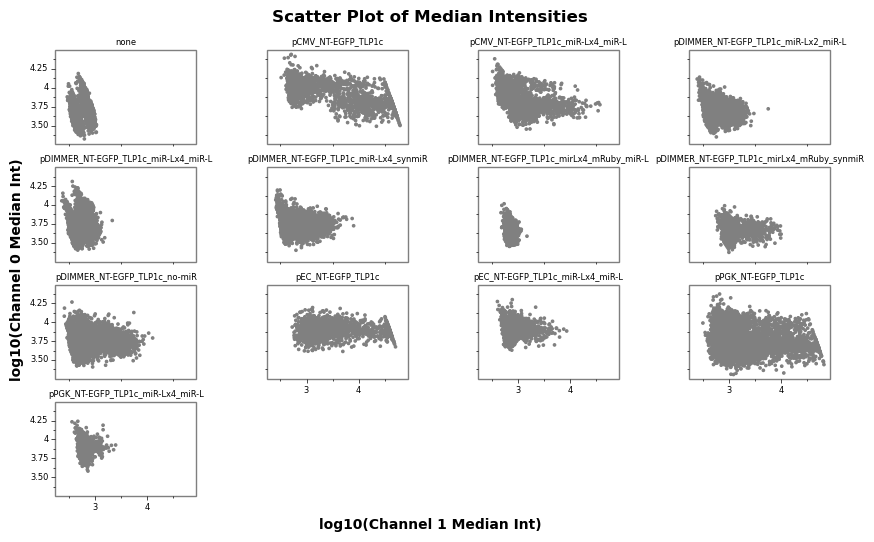

In [179]:
# Make the same scatterplot as above, using the corrected data
plot = (
    p9.ggplot(data = wide_df, 
              mapping = p9.aes(x = 'cor_ch1_log10_median', 
                               y = 'ch0_log10_median')) +  # Set aesthetic mappings
    p9.geom_point(size = 0.5, color = 'gray') +  # Add points for scatter plot
    p9.labs(
        title = 'Scatter Plot of Median Intensities',
        x = 'log10(Channel 1 Median Int)',
        y = 'log10(Channel 0 Median Int)'
    ) + 
    p9.facet_wrap(' ~ plasmid') +  # Create separate plots for each channel
    p9.theme_bw() +  # Use a clean theme
    p9.theme(
        figure_size = (10, 6),  # Set the size of the plot
        aspect_ratio = 1/2,
        subplots_adjust = {'wspace': 0.50},  # Adjust space between plots
        panel_grid = p9.element_blank(),  # Hide grid lines
        legend_position = 'none',  # Hide legend if desired
        plot_background = p9.element_rect(fill='white'),  # Set background to white
        axis_ticks = p9.element_line(color = 'black', linewidth = 0.5), 
        plot_title = p9.element_text(size = 12, color = 'black', face = 'bold'),
        axis_text = p9.element_text(size = 6, color = 'black'), 
        axis_title = p9.element_text(size = 10, color = 'black', face = 'bold'), 
        legend_text = p9.element_text(size = 6, color = 'black'), 
        legend_title = p9.element_text(size = 10, color = 'black', face = 'bold'), 
        strip_text = p9.element_text(size = 6, color = 'black'), 
        strip_background = p9.element_blank()
    )
)

# Print the plot
print(plot)

In [31]:
# Use a thresholding approach to classify cells according to GFP expression

# Define conservative hard thresholds for GFP and mRuby
#gfp_threshold = 2.65
#rfp_threshold = 2.3

# Or define a threshold based on untransfected cells (115% of the median CH2 value)
#utx_df = wide_df[wide_df['plasmid'] == 'none']
#gfp_threshold = np.median(utx_df['ch1_log10_median']) + (3 * np.sd(utx_df['ch1_log10_median']))
#rfp_threshold = np.median(utx_df['ch2_log10_median']) + (3 * np.sd(utx_df['ch2_log10_median']))

# Apply threshold to classify cells
#wide_df['tx_status_thr'] = np.where(wide_df['cor_ch1_log10_median'] <= my_threshold, "N", "Y")

def apply_threshold(group, threshold=None):
    # If a threshold is provided, use that; otherwise, calculate dynamically
    if threshold is None:
        # Calculate threshold based on untransfected cells
        utx_df = group[group['plasmid'] == 'none']
        if len(utx_df) > 0:
            ch1_threshold = np.median(utx_df['ch1_log10_median']) + (3 * np.std(utx_df['ch1_log10_median']))
            ch2_threshold = np.median(utx_df['ch2_log10_median']) + (3 * np.std(utx_df['ch2_log10_median']))
        else:
            ch1_threshold = 2.65  # Default hard threshold if no 'none' plasmid is found
            ch2_threshold = 2.3
    else:
        ch1_threshold, ch2_threshold = threshold

    # Apply threshold to classify cells
    group['tx_status_thr'] = np.where(
        (group['ch1_log10_median'] > ch1_threshold) | (group['ch2_log10_median'] > ch2_threshold),
        "Y", "N"
    )

    
    return group

# Apply the function to each group defined by 'experiment_folder'
wide_df = wide_df.groupby('experiment').apply(apply_threshold).reset_index(drop=True)

In [149]:
# Use a Gaussian Mixture Model (GMM) to cluster cells as transfected or untransfected

from sklearn.mixture import GaussianMixture

def apply_gmm(group):
    # Reshape the data for clustering (based on 'cor_ch1_log2_median')
    X = group['cor_ch1_log2_median'].values.reshape(-1, 1)
    
    # Fit the Gaussian Mixture Model with two components
    gmm = GaussianMixture(n_components=2, random_state=0).fit(X)
    
    # Predict the cluster each data point belongs to
    group['cluster'] = gmm.predict(X)
    
    # Determine which cluster corresponds to untransfected cells (based on means)
    negative_lbl = 0 if gmm.means_[0] < gmm.means_[1] else 1
    
    # Assign transfection status based on the clusters
    group['tx_status_gmm'] = np.where(group['cluster'] == negative_lbl, "N", "Y")
    
    return group

# Apply GMM clustering to each group in wide_df grouped by 'experiment_folder'
wide_df = wide_df.groupby('experiment_folder').apply(apply_gmm)

# Reset the index if necessary
wide_df.reset_index(drop=True, inplace=True)

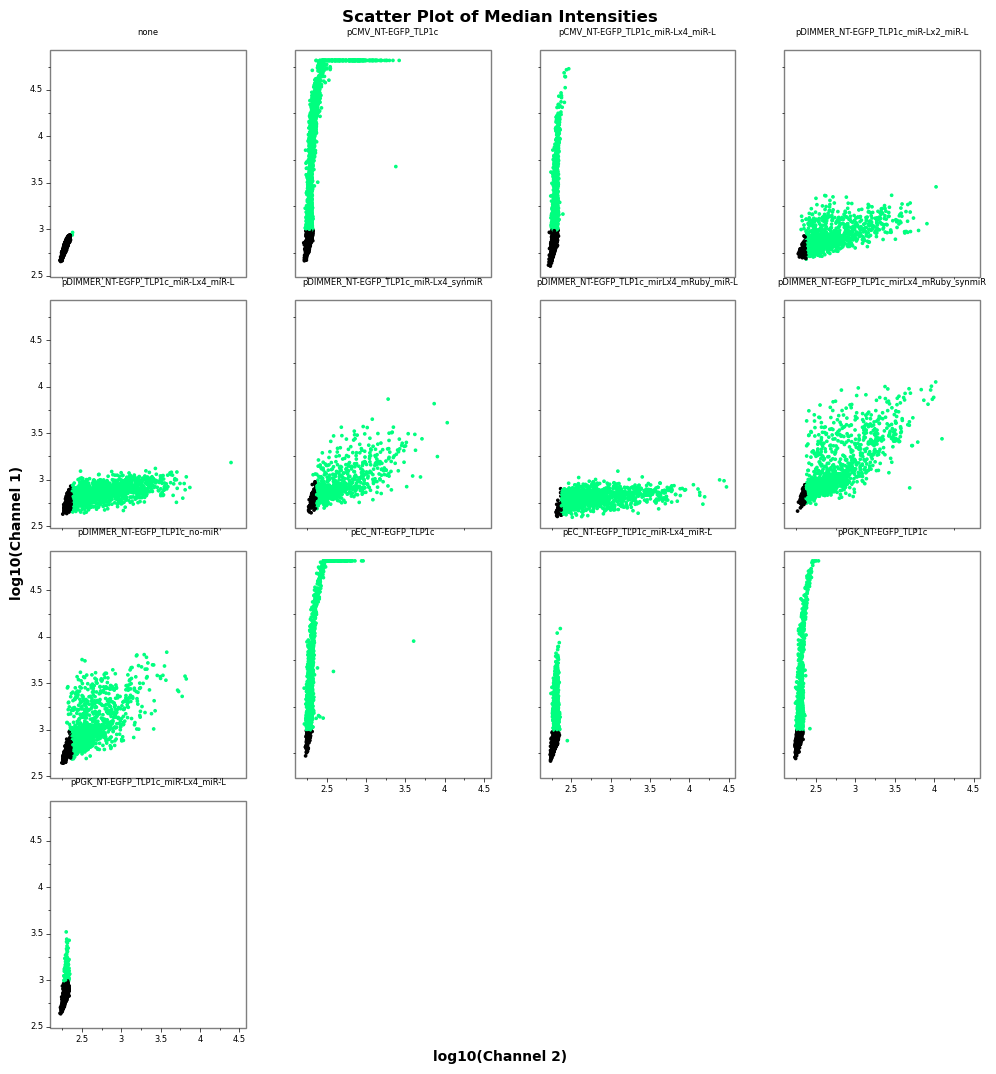

In [55]:
# Make the same scatterplot as above, coloring cells by group this time
group_colors = {"N": 'black', "Y": 'springgreen'}

# Define some list of values to filter by
my_plasmids = ['pDIMMER_NT-EGFP_TLP1c_no-miR', 'pDIMMER_NT-EGFP_TLP1c_miR-Lx4_synmiR',
               'pDIMMER_NT-EGFP_TLP1c_miR-Lx4_miR-L', 'pDIMMER_NT-EGFP_TLP1c_miR-Lx2_miR-L', 
               'pPGK_NT-EGFP_TLP1c', 'pDIMMER_NT-EGFP_TLP1c_mirLx4_mRuby_miR-L',
               'pDIMMER_NT-EGFP_TLP1c_mirLx4_mRuby_synmiR', 'none']
aug_experiments = ['08052024_pDIMMERs', '08122024_pDIMMERs']
oct_experiments = ['10032024_pDIMMERs', '10072024_pDIMMERs']

my_data = wide_df[wide_df['experiment'].isin(oct_experiments)]

plot = (
    p9.ggplot(data = my_data, 
              mapping = p9.aes(x = 'ch2_log10_median', 
                               y = 'ch1_log10_median', 
                               color = 'tx_status_thr')) +  # Set aesthetic mappings
    p9.geom_point(size = 0.5) +  # Add points for scatter plot
    #p9.geom_vline(xintercept = 9.5, linetype = 'dashed') + 
    p9.labs(
        title = 'Scatter Plot of Median Intensities',
        x = 'log10(Channel 2)',
        y = 'log10(Channel 1)'
    ) + 
    p9.facet_grid(' ~ plasmid') +  # Create separate plots for each channel
    p9.theme_bw() +  # Use a clean theme
    p9.scale_color_manual(values = group_colors) + 
    p9.theme(
        figure_size = (12, 6),  # Set the size of the plot
        aspect_ratio = 1,
        subplots_adjust = {'wspace': 0.25},  # Adjust space between plots
        panel_grid = p9.element_blank(),  # Hide grid lines
        legend_position = 'none',  # Hide legend if desired
        plot_background = p9.element_rect(fill='white'),  # Set background to white
        axis_ticks = p9.element_line(color = 'black', linewidth = 0.5), 
        plot_title = p9.element_text(size = 12, color = 'black', face = 'bold'),
        axis_text = p9.element_text(size = 6, color = 'black'), 
        axis_title = p9.element_text(size = 10, color = 'black', face = 'bold'), 
        legend_text = p9.element_text(size = 6, color = 'black'), 
        legend_title = p9.element_text(size = 10, color = 'black', face = 'bold'), 
        strip_text = p9.element_text(size = 6, color = 'black'), 
        strip_background = p9.element_blank()
    )
)

# Print the plot
print(plot)

In [41]:
print(wide_df.head())

   image_index                                           filename  \
0            0  05082024_pDIMMERs_pDIMMER_EGFP_TLP1c_miR-Lx2_m...   
1            0  05082024_pDIMMERs_pDIMMER_EGFP_TLP1c_miR-Lx2_m...   
2            0  05082024_pDIMMERs_pDIMMER_EGFP_TLP1c_miR-Lx2_m...   
3            0  05082024_pDIMMERs_pDIMMER_EGFP_TLP1c_miR-Lx2_m...   
4            0  05082024_pDIMMERs_pDIMMER_EGFP_TLP1c_miR-Lx2_m...   

          experiment                              plasmid promoter  miRNA  \
0  08052024_pDIMMERs  pDIMMER_NT-EGFP_TLP1c_miR-Lx2_miR-L     pECM  miR-L   
1  08052024_pDIMMERs  pDIMMER_NT-EGFP_TLP1c_miR-Lx2_miR-L     pECM  miR-L   
2  08052024_pDIMMERs  pDIMMER_NT-EGFP_TLP1c_miR-Lx2_miR-L     pECM  miR-L   
3  08052024_pDIMMERs  pDIMMER_NT-EGFP_TLP1c_miR-Lx2_miR-L     pECM  miR-L   
4  08052024_pDIMMERs  pDIMMER_NT-EGFP_TLP1c_miR-Lx2_miR-L     pECM  miR-L   

  target_sites  ROI_index  ch0_log10_median  ch1_log10_median  \
0            2          1          3.492341          2.51

In [47]:
# Save the cell classification to a .csv file on disk
subset_df = wide_df[['filename', 'plasmid', 'experiment', 'ROI_index', 'ch1_log10_median', 'tx_status_thr']]
#print(subset_df.head())
subset_df.to_csv(os.path.join(repo_directory, "pDIMMERs_cell-class.csv"), index = False)